# GW parameter estimation with PTMCMC

We use the IMRPhenomD $h_{22}$ waveform model to simulate (noise-free) data and recover the parameters via parallel tempering MCMC. The noise weighted inner product uses the aLIGO theoretical noise PSD. All inner products, likelihood evaluations, etc. are conducted in the frequency-domain.

I (jimmy :]) use MCMC to compute the effects of suppressing tail terms (1.5-3.5PN order, encompassing first-order tails to 2nd-order nonlinear Christodoulou memory) in the waveform. Of interest are the Bayes factor between the untouched waveform and variously suppressed waveforms as a multivariate function of the toggling parameters (lambda15 thru lambda35).

## PN Terms by Order
- 1.5PN: first-order tail term; 
- 2.5PN: Christodoulou memory term and corrections to the 1.5PN tail term; 
- 3PN: second-order tail/tail-of-tail term; 
- 3.5PN: Christodoulou memory correction

In [1]:
import lambdasMCMC as lmcmc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### Initialize plots

## Only NEED the <lnL> vs beta plot, but DO write functionality to make diagnostic plots like: 
# time/freq-series strain,
# \Delta\Psi vs f, **STARTED
# lnL vs iteration, **STARTED
# \vec{\theta} vs iteration, **STARTED
# MAYBE posterior corner plots (for 1-2 arbitrary sets of toggle params) and bayesograms
## Figure out how to calculate lnZ's later
num_samples=10000
num_chains=15


Starting $lambda$MCMC
Running PTMCMC #1 for lambda15=0.13956439645928542, lambda25=0.9571334704929654, lambda3=0.27652184087952436, lambda35=0.4440448866940653...


c:\Users\johor\OneDrive\Documents\GitHub\GWTails_ParameterEstimation\PTMCMC.py:54: RuntimeWarning: overflow encountered in exp
  acc_ratio = np.exp(log_acc_ratio)


Final spin (Mf=-0.776272) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.771508) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.776272) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.761791) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.776272) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.776272) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.776272) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.776272) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.776269) and ISCO frequency of this system are small, the model might misbehave here.
Final spin (Mf=-0.776269) and ISCO frequency of this system are small, th

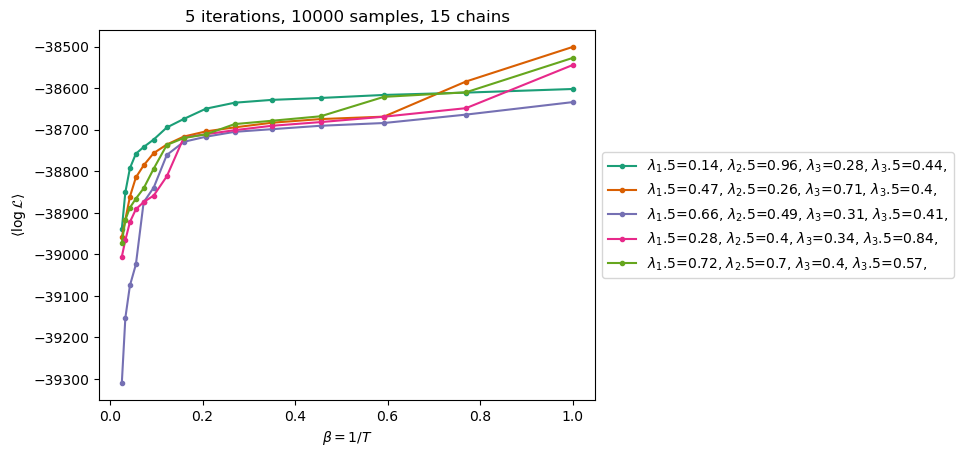

In [ ]:
lambdas=list(zip(lmcmc.lambda15s, lmcmc.lambda25s, lmcmc.lambda3s, lmcmc.lambda35s))
num_lmcmciters=len(lambdas)

fig,ax = plt.subplots()
colors=lmcmc.itercolors

i=1
print('Starting $lambda$MCMC')
for lambda15, lambda25, lambda3, lambda35 in lambdas:
    print(f'Running PTMCMC #{i} for lambda15={lambda15}, lambda25={lambda25}, lambda3={lambda3}, lambda35={lambda35}...')

    # Do PTMCMC for this set of lambda values
    samples, lnposts, temp_ladder = lmcmc.PTMCMC_i(lambdas=[lambda15, lambda25, lambda3, lambda35], 
                                                   num_samples=num_samples,
                                                   num_chains=num_chains)
    
    # Plot results
    betas, avg_lnlikes = lmcmc.avglnlikes_vs_betas(temp_ladder, lnposts, num_samples)
    ax.plot(betas, avg_lnlikes, marker='.', color=colors[i-1], label=f'$\lambda_{15}$={round(lambda15,2)}, $\lambda_{25}$={round(lambda25,2)}, $\lambda_{3}$={round(lambda3,2)}, $\lambda_{35}$={round(lambda35,2)},')
    
    # Perform thermodynamic integration
    # ...
    
    # Calculate bayes factor WRT unsuppressed waveform

    # finish i-th iteration
    i+=1

ax.set_title(f'{num_lmcmciters} iterations, {num_samples} samples, {num_chains} chains')
ax.set_xlabel(r'$\beta = 1 / T$')
ax.set_ylabel(r'$\langle\log\mathcal{L}\rangle$')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.show()